# Baseline Analysis — pub-002 (16k tokens, public split)

Local analysis of `data/full_public_16k.jsonl` + `data/full_public_16k.responses.jsonl`.

Companion to [`baseline_analysis.ipynb`](baseline_analysis.ipynb) (pub-001 / 8k). MCQ section is **basic** only; free-form and topic sections follow the 8k notebook.

In [1]:
import json
import re
import os
import sys
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if not os.path.isdir(os.path.join(REPO_ROOT, "data")):
    REPO_ROOT = os.getcwd()

sys.path.insert(0, REPO_ROOT)

RUN_TAG = "16k"
RESULTS_PATH = os.path.join(REPO_ROOT, "data", f"full_public_{RUN_TAG}.jsonl")
RESPONSES_PATH = os.path.join(REPO_ROOT, "data", f"full_public_{RUN_TAG}.responses.jsonl")
TOPICS_PATH = os.path.join(REPO_ROOT, "data", f"full_public_{RUN_TAG}_topics.json")
MAX_TOKENS = 16_384
NEAR_CAP_CHARS = 56_000  # legacy char heuristic (8k notebook used 28k)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("REPO_ROOT:", REPO_ROOT)
print("Results:", RESULTS_PATH)

REPO_ROOT: /home/andrewyin/UCSD-CSE-Programming-Assignments/CSE151B/151B_SP26_Competition
Results: /home/andrewyin/UCSD-CSE-Programming-Assignments/CSE151B/151B_SP26_Competition/data/full_public_16k.jsonl


## 1. Load data

In [2]:
def load_jsonl(path):
    with open(path) as f:
        return [json.loads(l) for l in f]

results   = load_jsonl(RESULTS_PATH)
responses = load_jsonl(RESPONSES_PATH)
public    = load_jsonl(os.path.join(REPO_ROOT, "data", "public.jsonl"))

resp_map = {r["id"]: r["response"] for r in responses}
pub_map  = {p["id"]: p for p in public}

rows = []
for r in results:
    pid  = r["id"]
    p    = pub_map[pid]
    resp = resp_map.get(pid, "")
    rows.append({
        "id":               pid,
        "is_mcq":           r["is_mcq"],
        "correct":          r["correct"],
        "response":         resp,
        "resp_len":         len(resp),
        "question":         p.get("question", ""),
        "q_len":            len(p.get("question", "")),
        "gold":             r["gold"],
        "n_blanks":         len(r["gold"]) if isinstance(r["gold"], list) else 1,
        "has_boxed_letter": bool(re.search(r"\\boxed\{([A-Z])\}", resp)),
        "think_finished":   "</think>" in resp,
        "near_cap_chars":   len(resp) >= NEAR_CAP_CHARS,
    })

df = pd.DataFrame(rows)
mcq = df[df.is_mcq]
ff  = df[~df.is_mcq]

print(f"Loaded {len(df)} rows  |  MCQ: {df.is_mcq.sum()}  |  Free-form: {(~df.is_mcq).sum()}")
print(f"Think finished: {df.think_finished.sum()} / {len(df)} ({100*df.think_finished.mean():.1f}%)")
print(f"Think truncated (no </think>): {(~df.think_finished).sum()} ({100*(~df.think_finished).mean():.1f}%)")

Loaded 1126 rows  |  MCQ: 375  |  Free-form: 751
Think finished: 1048 / 1126 (93.1%)
Think truncated (no </think>): 78 (6.9%)


## 2. Headline metrics

In [3]:
def acc(mask):
    sub = df[mask]
    n, k = len(sub), sub.correct.sum()
    return n, k, 100 * k / n if n else 0

all_n, all_k, all_acc = acc(slice(None))
mcq_n, mcq_k, mcq_acc = acc(df.is_mcq)
ff_n,  ff_k,  ff_acc  = acc(~df.is_mcq)

print(f"{'Split':<15} {'N':>6} {'Correct':>8} {'Accuracy':>9}")
print("-" * 42)
print(f"{'Overall':<15} {all_n:>6} {all_k:>8} {all_acc:>8.2f}%")
print(f"{'MCQ':<15} {mcq_n:>6} {mcq_k:>8} {mcq_acc:>8.2f}%")
print(f"{'Free-form':<15} {ff_n:>6} {ff_k:>8} {ff_acc:>8.2f}%")

# pub-001 reference (8k full public)
pub001 = {"overall": 52.66, "mcq": 50.40, "ff": 53.79}
print()
print("Δ vs pub-001 (8k):")
print(f"  Overall:   {all_acc - pub001['overall']:+.2f} pp")
print(f"  MCQ:       {mcq_acc - pub001['mcq']:+.2f} pp")
print(f"  Free-form: {ff_acc - pub001['ff']:+.2f} pp")

Split                N  Correct  Accuracy
------------------------------------------
Overall           1126      697    61.90%
MCQ                375      270    72.00%
Free-form          751      427    56.86%

Δ vs pub-001 (8k):
  Overall:   +9.24 pp
  MCQ:       +21.60 pp
  Free-form: +3.07 pp


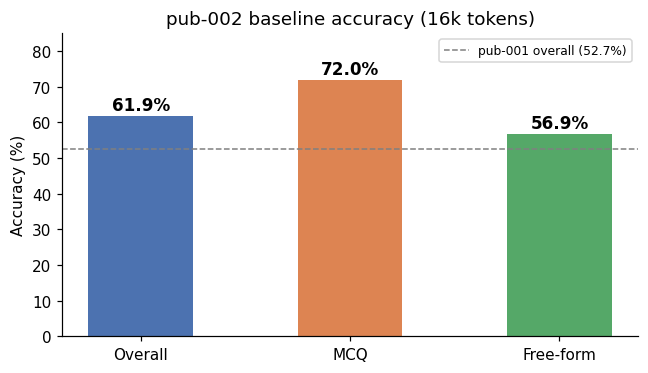

In [4]:
labels = ["Overall", "MCQ", "Free-form"]
accs   = [all_acc, mcq_acc, ff_acc]
colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(labels, accs, color=colors, width=0.5)
for bar, v in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.5, f"{v:.1f}%",
            ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.axhline(pub001["overall"], color="gray", ls="--", lw=1, label="pub-001 overall (52.7%)")
ax.set_ylim(0, 85)
ax.set_ylabel("Accuracy (%)")
ax.set_title("pub-002 baseline accuracy (16k tokens)")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## 3. MCQ (basic)

Format compliance and wrong-MCQ failure modes. No sample dumps — see `baseline_analysis.ipynb` §3 for the 8k deep-dive.

In [5]:
strict_n     = mcq[mcq.has_boxed_letter]
fallback_n   = mcq[~mcq.has_boxed_letter]
strict_correct = strict_n[strict_n.correct]
boxed_rate   = len(strict_correct) / len(strict_n) if len(strict_n) else 0

print("MCQ format compliance")
print(f"  Has \\boxed{{Letter}}:  {len(strict_n):>4}  ({100*len(strict_n)/len(mcq):.1f}%)")
print(f"    → correct:         {len(strict_correct):>4}  ({100*boxed_rate:.1f}% of boxed)")
print(f"  No \\boxed{{Letter}}:   {len(fallback_n):>4}  ({100*len(fallback_n)/len(mcq):.1f}%)")
print(f"    → correct:         {fallback_n.correct.sum():>4}  ({100*fallback_n.correct.mean():.1f}% of fallback)")
print()

wrong_mcq       = mcq[~mcq.correct]
truncated       = (~wrong_mcq.think_finished).sum()
finished_no_box = (wrong_mcq.think_finished & ~wrong_mcq.has_boxed_letter).sum()
wrong_box       = (wrong_mcq.think_finished &  wrong_mcq.has_boxed_letter).sum()

print("Wrong MCQ failure modes")
print(f"  Total wrong:                                {len(wrong_mcq)}")
print(f"  Truncated mid-think (no </think>):          {truncated:>4}  ({100*truncated/len(wrong_mcq):.1f}%)")
print(f"  Think finished, no \\boxed{{Letter}}:        {finished_no_box:>4}  ({100*finished_no_box/len(wrong_mcq):.1f}%)")
print(f"  Think finished, wrong \\boxed{{Letter}}:     {wrong_box:>4}  ({100*wrong_box/len(wrong_mcq):.1f}%)")

MCQ format compliance
  Has \boxed{Letter}:   323  (86.1%)
    → correct:          269  (83.3% of boxed)
  No \boxed{Letter}:     52  (13.9%)
    → correct:            1  (1.9% of fallback)

Wrong MCQ failure modes
  Total wrong:                                105
  Truncated mid-think (no </think>):            43  (41.0%)
  Think finished, no \boxed{Letter}:           8  (7.6%)
  Think finished, wrong \boxed{Letter}:       54  (51.4%)


## 4. Free-form: single vs multi-blank

In [6]:
single = ff[ff.n_blanks == 1]
multi  = ff[ff.n_blanks > 1]

print(f"Single-blank:  {len(single):>4}  acc={100*single.correct.mean():.1f}%")
print(f"Multi-blank:   {len(multi):>4}  acc={100*multi.correct.mean():.1f}%")
print()
print("Multi-blank distribution:")
print(ff.n_blanks.value_counts().sort_index())

Single-blank:   337  acc=60.2%
Multi-blank:    414  acc=54.1%

Multi-blank distribution:
n_blanks
1     337
2     171
3      90
4      59
5      31
6      20
7      12
8      12
9       4
10      5
11      1
12      2
13      1
14      2
15      2
24      1
42      1
Name: count, dtype: int64


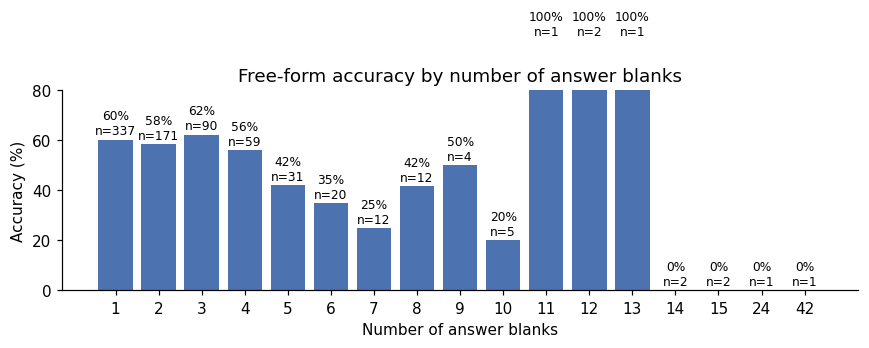

In [7]:
blank_acc = ff.groupby("n_blanks").agg(n=("correct", "count"), acc=("correct", "mean")).reset_index()
blank_acc["acc"] *= 100

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.bar(blank_acc.n_blanks.astype(str), blank_acc.acc, color="#4C72B0")
for bar, row in zip(bars, blank_acc.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, row.acc + 0.8,
            f"{row.acc:.0f}%\nn={row.n}", ha="center", va="bottom", fontsize=8)
ax.set_xlabel("Number of answer blanks")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Free-form accuracy by number of answer blanks")
ax.set_ylim(0, 80)
plt.tight_layout()
plt.show()

## 4b. Free-form format compliance

Post-thinking tail (text after the model closes its thinking block) must yield **N** `\boxed{…}` answers in the **last contiguous group** (`judger.extract_all_boxed`) matching **N** `[ANS]` blanks. **Misformat** = extracted box count ≠ blank count. **Wrong order** (multi-blank only) = count matches and normalized box values are a multiset match with gold but not in blank order (grader is position-sensitive).

In [8]:
import importlib.util
from collections import Counter
from itertools import permutations

_spec = importlib.util.spec_from_file_location(
    "sft_prompt", os.path.join(REPO_ROOT, "scripts", "sft_prompt.py")
)
_sft_prompt = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_sft_prompt)
extract_all_boxed = _sft_prompt.extract_all_boxed


THINK_END = "</" + "redacted_thinking>"


def response_tail(resp: str) -> str:
    end = resp.rfind(THINK_END)
    return resp[end + len(THINK_END):] if end >= 0 else resp


def count_raw_boxed(text: str) -> int:
    n, start = 0, 0
    while True:
        idx = text.find("\\boxed{", start)
        if idx < 0:
            break
        n += 1
        i = idx + len("\\boxed{")
        depth = 1
        while i < len(text) and depth > 0:
            if text[i] == "{":
                depth += 1
            elif text[i] == "}":
                depth -= 1
            i += 1
        start = i
    return n


_PERMUTE_ORDER_MAX_BLANKS = 8


def _norm_box(judger, s: str) -> str:
    return judger.normalize_answer(s)


def _multiset_norm_ok(judger, boxes, gold) -> bool:
    if len(boxes) != len(gold):
        return False
    pb = [_norm_box(judger, b) for b in boxes]
    gb = [_norm_box(judger, g) for g in gold]
    return Counter(pb) == Counter(gb)


def _identity_norm_ok(judger, boxes, gold) -> bool:
    if len(boxes) != len(gold):
        return False
    return [_norm_box(judger, b) for b in boxes] == [_norm_box(judger, g) for g in gold]


def _any_order_semantic_ok(judger, boxes, gold) -> bool:
    """Some permutation matches gold slot-wise (judger.is_equal); n capped for cost."""
    n = len(gold)
    if len(boxes) != n or n == 0:
        return False
    if n == 1:
        return judger.is_equal(
            judger.norm_ans_str(boxes[0]), judger.norm_ans_str(gold[0]), options=[]
        )
    if not _multiset_norm_ok(judger, boxes, gold):
        return False
    if _identity_norm_ok(judger, boxes, gold):
        return True
    if n > _PERMUTE_ORDER_MAX_BLANKS:
        return False
    pred_norm = [judger.norm_ans_str(b) for b in boxes]
    gold_norm = [judger.norm_ans_str(g) for g in gold]
    return any(
        all(
            judger.is_equal(pred_norm[perm[i]], gold_norm[i], options=[])
            for i in range(n)
        )
        for perm in permutations(range(n))
    )


try:
    from judger import Judger

    _judger = Judger(strict_extract=False)
except Exception as _judger_exc:
    _judger = None
    print(f"Order check unavailable ({_judger_exc}).\n")


def _gold_list(gold):
    return gold if isinstance(gold, list) else [gold]


ff_fmt = ff.copy()
_tails = ff_fmt["response"].map(response_tail)
ff_fmt["boxed"] = _tails.map(extract_all_boxed)
ff_fmt["n_extracted"] = ff_fmt["boxed"].map(len)
ff_fmt["n_raw_boxed"] = _tails.map(count_raw_boxed)
ff_fmt["count_ok"] = ff_fmt["n_extracted"] == ff_fmt["n_blanks"]
ff_fmt["no_boxed"] = ff_fmt["n_extracted"] == 0
ff_fmt["count_short"] = (ff_fmt["n_extracted"] > 0) & (ff_fmt["n_extracted"] < ff_fmt["n_blanks"])
ff_fmt["count_long"] = ff_fmt["n_extracted"] > ff_fmt["n_blanks"]
ff_fmt["non_contiguous"] = ff_fmt["n_raw_boxed"] > ff_fmt["n_extracted"]
_has_think_tags = ff_fmt["think_finished"].any()
ff_fmt["format_bad"] = ~ff_fmt["count_ok"]

if _judger is not None:
    ff_fmt["multiset_norm_ok"] = ff_fmt.apply(
        lambda r: _multiset_norm_ok(_judger, r["boxed"], _gold_list(r["gold"])), axis=1
    )
    ff_fmt["identity_norm_ok"] = ff_fmt.apply(
        lambda r: _identity_norm_ok(_judger, r["boxed"], _gold_list(r["gold"])), axis=1
    )
    ff_fmt["wrong_order"] = (
        ff_fmt["count_ok"]
        & ~ff_fmt["correct"]
        & (ff_fmt["n_blanks"] >= 2)
        & ff_fmt["multiset_norm_ok"]
        & ~ff_fmt["identity_norm_ok"]
    )
    _order_cand = ff_fmt["wrong_order"]
    if _order_cand.any():
        ff_fmt.loc[_order_cand, "wrong_order"] = _order_cand & ff_fmt.loc[_order_cand].apply(
            lambda r: _any_order_semantic_ok(_judger, r["boxed"], _gold_list(r["gold"])),
            axis=1,
        )
else:
    ff_fmt["wrong_order"] = False

count_ok_ff = ff_fmt[ff_fmt.count_ok]
format_bad_ff = ff_fmt[ff_fmt.format_bad]
finished_ff = ff_fmt[ff_fmt.think_finished] if _has_think_tags else ff_fmt

print("Free-form format compliance (judger extract_all_boxed on answer tail)")
if not _has_think_tags:
    print("  (No thinking-close tags in responses — tail = full trace, same judger fallback.)\n")
else:
    print(f"  Think-finished subset: {len(finished_ff)} / {len(ff_fmt)} rows\n")

print(f"  Extracted count == blanks: {len(count_ok_ff):>4}  ({100*len(count_ok_ff)/len(ff_fmt):.1f}% of FF)")
print(f"    → correct (ordered grader): {count_ok_ff.correct.sum():>4}  ({100*count_ok_ff.correct.mean():.1f}% of count-ok)")
_wrong_count_ok = count_ok_ff[~count_ok_ff.correct]
_ff_wrong_order_n = int(ff_fmt.wrong_order.sum())
_ff_wrong_vals_n = len(_wrong_count_ok) - _ff_wrong_order_n
if len(_wrong_count_ok):
    print(f"    → wrong order (n≥2, permuted): {_ff_wrong_order_n:>4}  "
          f"({100*_ff_wrong_order_n/len(_wrong_count_ok):.1f}% of count-ok wrong)")
    print(f"    → wrong values (not reorder): {_ff_wrong_vals_n:>4}  "
          f"({100*_ff_wrong_vals_n/len(_wrong_count_ok):.1f}% of count-ok wrong)")
print(f"  Misformat (count ≠ blanks):  {len(format_bad_ff):>4}  ({100*len(format_bad_ff)/len(ff_fmt):.1f}% of FF)")
print(f"    no \\boxed{{}}:             {format_bad_ff.no_boxed.sum():>4}")
print(f"    too few boxes:             {format_bad_ff.count_short.sum():>4}")
print(f"    too many boxes:            {format_bad_ff.count_long.sum():>4}")
print(f"    → correct (any):           {format_bad_ff.correct.sum():>4}")
print()
print(f"  Extra \\boxed{{}} before last group (raw > extracted): "
      f"{ff_fmt.non_contiguous.sum():>4}  "
      f"({100*ff_fmt.non_contiguous.mean():.1f}% of FF; "
      f"{(ff_fmt.non_contiguous & ff_fmt.count_ok).sum()} still count-ok)")
print()

wrong_ff = ff_fmt[~ff_fmt.correct]
trunc_wrong_ff = (~wrong_ff.think_finished).sum() if _has_think_tags else 0
ff_misformat = (~wrong_ff.count_ok).sum()
ff_fin_no_box = wrong_ff.no_boxed.sum()
ff_fin_short = wrong_ff.count_short.sum()
ff_fin_long = wrong_ff.count_long.sum()
ff_reasoning = wrong_ff.count_ok.sum()
ff_wrong_order = int(wrong_ff.wrong_order.sum())
ff_wrong_values = ff_reasoning - ff_wrong_order

print("Wrong free-form failure modes")
print(f"  Total wrong:                          {len(wrong_ff)}")
if _has_think_tags:
    print(f"  Truncated mid-think:                  {trunc_wrong_ff:>4}  ({100*trunc_wrong_ff/len(wrong_ff):.1f}%)")
print(f"  Misformat (extracted count ≠ blanks): {ff_misformat:>4}  ({100*ff_misformat/len(wrong_ff):.1f}%)")
print(f"    no \\boxed{{}}:                       {ff_fin_no_box:>4}")
print(f"    too few / too many boxes:           {ff_fin_short + ff_fin_long:>4}  "
      f"(short {ff_fin_short}, long {ff_fin_long})")
print(f"  Count ok — wrong values:              {ff_wrong_values:>4}  ({100*ff_wrong_values/len(wrong_ff):.1f}%)")
print(f"  Count ok — wrong order (n≥2):         {ff_wrong_order:>4}  ({100*ff_wrong_order/len(wrong_ff):.1f}%)")
print()

multi_fmt = ff_fmt[ff_fmt.n_blanks > 1]
wrong_multi = multi_fmt[~multi_fmt.correct]
multi_format_bad = (~wrong_multi.count_ok).sum()
print(f"Multi-blank only (n={len(multi_fmt)}): misformat among wrong = "
      f"{multi_format_bad} / {len(wrong_multi)} ({100*multi_format_bad/len(wrong_multi):.1f}% of wrong multi)")
_multi_wrong_order = int(wrong_multi.wrong_order.sum()) if "wrong_order" in wrong_multi.columns else 0
print(f"Multi-blank wrong order (reorder would fix): {_multi_wrong_order} / {len(wrong_multi)}")

Free-form format compliance (judger extract_all_boxed on answer tail)
  Think-finished subset: 717 / 751 rows

  Extracted count == blanks:  693  (92.3% of FF)
    → correct:                427  (61.6% of count-ok)
  Misformat (count ≠ blanks):    58  (7.7% of FF)
    no \boxed{}:               31
    too few boxes:               11
    too many boxes:              16
    → correct (any):              0

  Extra \boxed{} before last group (raw > extracted):  396  (52.7% of FF; 366 still count-ok)

Wrong free-form failure modes
  Total wrong:                          324
  Truncated mid-think:                    33  (10.2%)
  Misformat (extracted count ≠ blanks):   58  (17.9%)
    no \boxed{}:                         31
    too few / too many boxes:             27  (short 11, long 16)
  Count ok (reasoning / math error):     266  (82.1%)

Multi-blank only (n=414): misformat among wrong = 41 / 190 (21.6% of wrong multi)


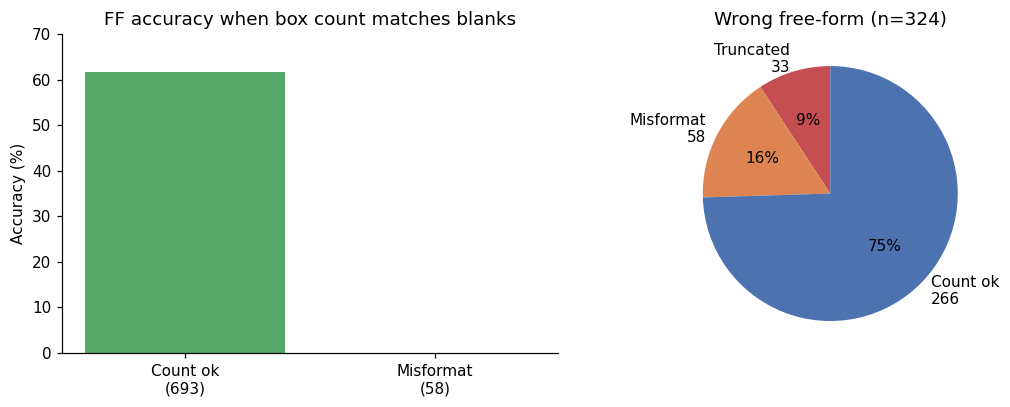

In [9]:
ff_fail_labels = []
ff_fail_sizes = []
ff_fail_colors = []
if _has_think_tags and trunc_wrong_ff:
    ff_fail_labels.append(f"Truncated\n{trunc_wrong_ff}")
    ff_fail_sizes.append(trunc_wrong_ff)
    ff_fail_colors.append("#C44E52")
ff_fail_labels += [
    f"Misformat\n{ff_misformat}",
    f"Wrong order\n{ff_wrong_order}",
    f"Wrong values\n{ff_wrong_values}",
]
ff_fail_sizes += [ff_misformat, ff_wrong_order, ff_wrong_values]
ff_fail_colors += ["#DD8452", "#C44E52", "#4C72B0"]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

ax = axes[0]
ok_n = len(count_ok_ff)
bad_n = len(format_bad_ff)
ax.bar(
    [f"Count ok\n({ok_n})", f"Misformat\n({bad_n})"],
    [count_ok_ff.correct.mean() * 100, 0],
    color=["#55A868", "#DD8452"],
)
ax.set_ylabel("Accuracy (%)")
ax.set_title("FF accuracy when box count matches blanks")
ax.set_ylim(0, 70)

ax = axes[1]
ax.pie(
    ff_fail_sizes,
    labels=ff_fail_labels,
    colors=ff_fail_colors,
    autopct=lambda p: f"{p:.0f}%" if p > 4 else "",
    startangle=90,
)
ax.set_title(f"Wrong free-form (n={len(wrong_ff)})")

plt.tight_layout()
plt.show()

## 5. Response length analysis

In [10]:
for label, mask in [("MCQ", df.is_mcq), ("Free-form", ~df.is_mcq)]:
    sub = df[mask]
    print(f"{label}  correct mean: {sub[sub.correct].resp_len.mean():,.0f} chars   "
          f"wrong mean: {sub[~sub.correct].resp_len.mean():,.0f} chars")

MCQ  correct mean: 16,981 chars   wrong mean: 31,219 chars
Free-form  correct mean: 7,308 chars   wrong mean: 18,151 chars


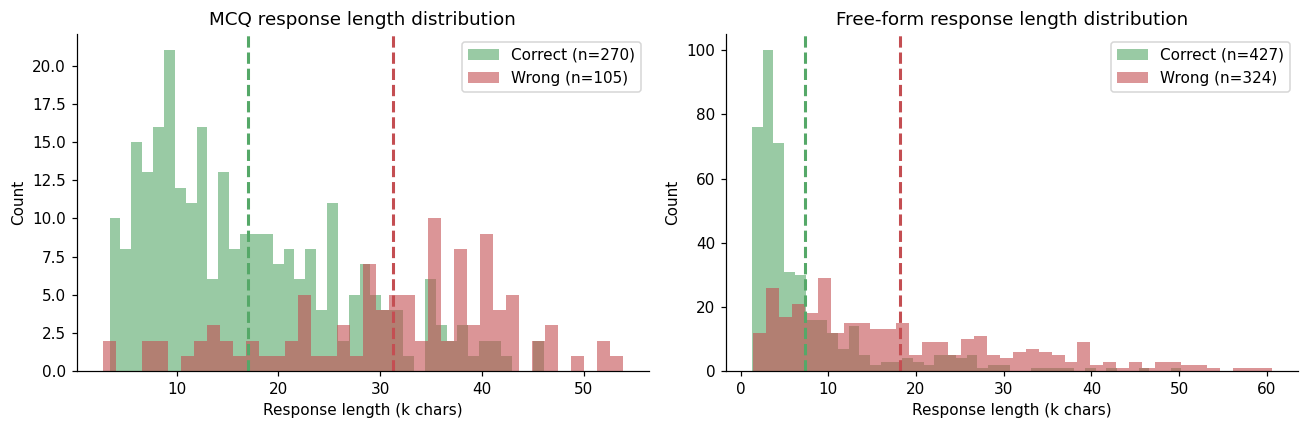

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, (label, mask) in zip(axes, [("MCQ", df.is_mcq), ("Free-form", ~df.is_mcq)]):
    sub = df[mask]
    corr  = sub[sub.correct].resp_len / 1000
    wrong = sub[~sub.correct].resp_len / 1000
    ax.hist(corr,  bins=40, alpha=0.6, color="#55A868", label=f"Correct (n={len(corr)})")
    ax.hist(wrong, bins=40, alpha=0.6, color="#C44E52", label=f"Wrong (n={len(wrong)})")
    ax.axvline(corr.mean(),  color="#55A868", lw=2, linestyle="--")
    ax.axvline(wrong.mean(), color="#C44E52", lw=2, linestyle="--")
    ax.set_xlabel("Response length (k chars)")
    ax.set_ylabel("Count")
    ax.set_title(f"{label} response length distribution")
    ax.legend()

plt.tight_layout()
plt.show()

## 6. Question length vs accuracy

In [12]:
corr_q  = df[df.correct].q_len.mean()
wrong_q = df[~df.correct].q_len.mean()
print(f"Correct question mean length:   {corr_q:.0f} chars")
print(f"Incorrect question mean length: {wrong_q:.0f} chars")

df["q_quartile"] = pd.qcut(df.q_len, 4, labels=["Q1 (short)", "Q2", "Q3", "Q4 (long)"])
q_acc = df.groupby("q_quartile", observed=True).agg(n=("correct", "count"), acc=("correct", "mean")).reset_index()
q_acc["acc"] *= 100
print()
print(q_acc.to_string(index=False))

Correct question mean length:   297 chars
Incorrect question mean length: 498 chars

q_quartile   n       acc
Q1 (short) 283 78.798587
        Q2 281 65.480427
        Q3 281 59.430605
 Q4 (long) 281 43.772242


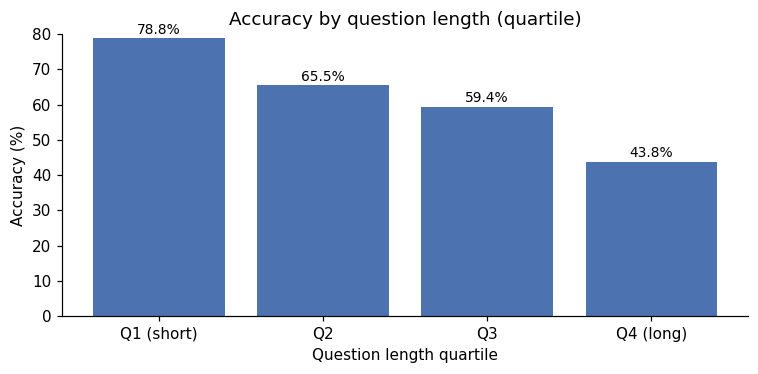

In [13]:
fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar(q_acc.q_quartile.astype(str), q_acc.acc, color="#4C72B0")
for bar, row in zip(bars, q_acc.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, row.acc + 0.5,
            f"{row.acc:.1f}%", ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Question length quartile")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy by question length (quartile)")
ax.set_ylim(0, 80)
plt.tight_layout()
plt.show()

## 7. Topic-level breakdown

In [14]:
TOPIC_PATTERNS = [
    ("sequences/recurrences", re.compile(r"sequence|recurrence|series|arithmetic|geometric|fibonacci", re.I)),
    ("geometry",              re.compile(r"triangle|circle|angle|polygon|area|perimeter|volume|surface|congruent|similar|parallelogram|trapezoid|chord|radius|diameter", re.I)),
    ("limits",               re.compile(r"\blimit\b|lim_|\\lim", re.I)),
    ("linear algebra",        re.compile(r"matrix|determinant|eigenvalue|eigenvector|vector space|rank|linear transform", re.I)),
    ("derivatives",          re.compile(r"derivative|differentiat|\\frac\{d|d/dx", re.I)),
    ("integration",          re.compile(r"integral|integrat|antiderivative|\\int", re.I)),
    ("probability/stats",    re.compile(r"probability|expected value|variance|distribution|random variable|combinat|permutation", re.I)),
    ("number theory",        re.compile(r"prime|divisib|modulo|congruence|gcd|lcm|diophantine", re.I)),
    ("polynomials/algebra",  re.compile(r"polynomial|quadratic|cubic|root|factor|expand|simplify|equation", re.I)),
]

def classify_topic(question: str) -> str:
    for name, pat in TOPIC_PATTERNS:
        if pat.search(question):
            return name
    return "other"

if os.path.isfile(TOPICS_PATH):
    with open(TOPICS_PATH) as f:
        topics_agg = json.load(f)
    print(f"Loaded topics from {TOPICS_PATH}")
else:
    topic_total, topic_correct = defaultdict(int), defaultdict(int)
    topic_mcq_t, topic_mcq_c = defaultdict(int), defaultdict(int)
    for r in results:
        q = pub_map[r["id"]]["question"]
        t = classify_topic(q)
        topic_total[t] += 1
        topic_correct[t] += int(r["correct"])
        if r["is_mcq"]:
            topic_mcq_t[t] += 1
            topic_mcq_c[t] += int(r["correct"])
    topics_agg = {
        t: {
            "n": topic_total[t],
            "correct": topic_correct[t],
            "accuracy": round(topic_correct[t] / topic_total[t] * 100, 2),
            "mcq_n": topic_mcq_t[t],
            "mcq_correct": topic_mcq_c[t],
            "mcq_accuracy": round(topic_mcq_c[t] / topic_mcq_t[t] * 100, 2) if topic_mcq_t[t] else None,
        }
        for t in topic_total
    }
    with open(TOPICS_PATH, "w") as f:
        json.dump(topics_agg, f, indent=2)
    print(f"Computed topics → {TOPICS_PATH}")

Loaded topics from /home/andrewyin/UCSD-CSE-Programming-Assignments/CSE151B/151B_SP26_Competition/data/full_public_16k_topics.json


In [15]:
topic_rows = []
for topic, v in topics_agg.items():
    topic_rows.append({
        "topic":        topic,
        "n":            v["n"],
        "correct":      v["correct"],
        "accuracy":     v["accuracy"],
        "mcq_n":        v["mcq_n"],
        "mcq_correct":  v["mcq_correct"],
        "mcq_accuracy": v["mcq_accuracy"],
    })

tdf = pd.DataFrame(topic_rows).sort_values("accuracy")

print(f"{'Topic':<30} {'N':>6} {'Acc':>7} {'MCQ N':>6} {'MCQ Acc':>9}")
print("-" * 65)
for _, r in tdf.iterrows():
    ma = r.mcq_accuracy if r.mcq_accuracy is not None else float("nan")
    print(f"{r.topic:<30} {r.n:>6} {r.accuracy:>6.1f}% {r.mcq_n:>6} {ma:>8.1f}%")

Topic                               N     Acc  MCQ N   MCQ Acc
-----------------------------------------------------------------
geometry                          115   50.4%     39     64.1%
number theory                      23   56.5%     21     57.1%
limits                             14   57.1%      7     85.7%
probability/stats                  82   58.5%     29     86.2%
sequences/recurrences              75   58.7%     61     63.9%
linear algebra                     23   60.9%     19     73.7%
other                             581   62.1%    102     64.7%
polynomials/algebra               146   63.7%     30     83.3%
derivatives                        12   83.3%     12     83.3%
integration                        55   87.3%     55     87.3%


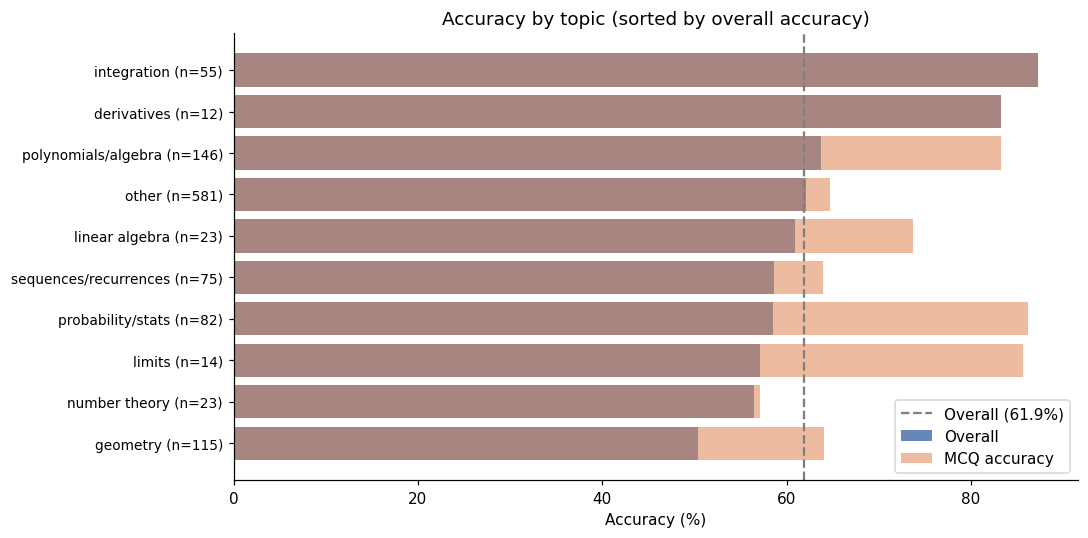

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
y = range(len(tdf))
ax.barh(list(y), tdf.accuracy, color="#4C72B0", alpha=0.85, label="Overall")
ax.barh(list(y), tdf.mcq_accuracy.fillna(0), color="#DD8452", alpha=0.55, label="MCQ accuracy")
ax.set_yticks(list(y))
ax.set_yticklabels([f"{t} (n={n})" for t, n in zip(tdf.topic, tdf.n)], fontsize=9)
ax.axvline(all_acc, color="gray", linestyle="--", lw=1.5, label=f"Overall ({all_acc:.1f}%)")
ax.set_xlabel("Accuracy (%)")
ax.set_title("Accuracy by topic (sorted by overall accuracy)")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Truncation check

In [17]:
trunc_all = (~df.think_finished).sum()
trunc_mcq = (~mcq.think_finished).sum()
trunc_ff  = (~ff.think_finished).sum()

print("Responses truncated mid-think (no </think> tag):")
print(f"  Overall:   {trunc_all} / {len(df)} ({100*trunc_all/len(df):.1f}%)")
print(f"  MCQ:       {trunc_mcq} / {len(mcq)} ({100*trunc_mcq/len(mcq):.1f}%)")
print(f"  Free-form: {trunc_ff} / {len(ff)} ({100*trunc_ff/len(ff):.1f}%)")
print()

trunc_df = df[~df.think_finished]
if len(trunc_df):
    mean_chars = trunc_df.resp_len.mean()
    est_ctok   = mean_chars / MAX_TOKENS
    print(f"Mean chars of truncated responses: {mean_chars:,.0f}")
    print(f"Implied chars/token at {MAX_TOKENS//1024}k cap: {est_ctok:.2f}")
print()

print("Accuracy by truncation status:")
for label, mask in [("Think finished", df.think_finished), ("Think truncated", ~df.think_finished)]:
    sub = df[mask]
    print(f"  {label:<20} n={len(sub):>4}  acc={100*sub.correct.mean():.1f}%")

old_trunc = df.near_cap_chars.sum()
print()
print(f"Legacy char-heuristic (≥{NEAR_CAP_CHARS//1000}k): {old_trunc}  |  tag-based truncated: {trunc_all}")

Responses truncated mid-think (no </think> tag):
  Overall:   78 / 1126 (6.9%)
  MCQ:       44 / 375 (11.7%)
  Free-form: 34 / 751 (4.5%)

Mean chars of truncated responses: 39,087
Implied chars/token at 16k cap: 2.39

Accuracy by truncation status:
  Think finished       n=1048  acc=66.3%
  Think truncated      n=  78  acc=2.6%

Legacy char-heuristic (≥56k): 3  |  tag-based truncated: 78


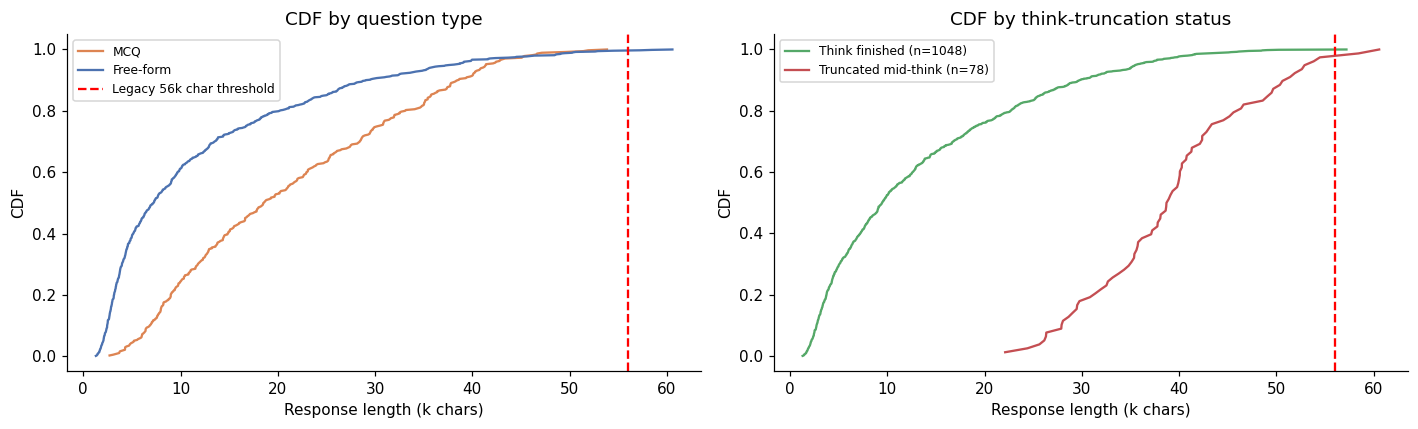

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for label, sub, color in [("MCQ", mcq, "#DD8452"), ("Free-form", ff, "#4C72B0")]:
    s = np.sort(sub.resp_len / 1000)
    ax.plot(s, np.arange(1, len(s)+1)/len(s), label=label, color=color)
ax.axvline(NEAR_CAP_CHARS / 1000, color="red", linestyle="--", lw=1.5, label=f"Legacy {NEAR_CAP_CHARS//1000}k char threshold")
ax.set_xlabel("Response length (k chars)")
ax.set_ylabel("CDF")
ax.set_title("CDF by question type")
ax.legend(fontsize=8)

ax = axes[1]
for label, mask, color in [
    ("Think finished", df.think_finished, "#55A868"),
    ("Truncated mid-think", ~df.think_finished, "#C44E52"),
]:
    sub = df[mask]
    s = np.sort(sub.resp_len / 1000)
    ax.plot(s, np.arange(1, len(s)+1)/len(s), label=f"{label} (n={len(sub)})", color=color)
ax.axvline(NEAR_CAP_CHARS / 1000, color="red", linestyle="--", lw=1.5)
ax.set_xlabel("Response length (k chars)")
ax.set_ylabel("CDF")
ax.set_title("CDF by think-truncation status")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 9. Summary table

In [19]:
best_topic  = tdf.iloc[-1]
weak_topic  = tdf.iloc[0]

summary = pd.DataFrame([
    {"Metric": "Overall accuracy", "Value": f"{all_acc:.2f}%  ({all_k}/{all_n})"},
    {"Metric": "MCQ accuracy", "Value": f"{mcq_acc:.2f}%  ({mcq_k}/{mcq_n})"},
    {"Metric": "Free-form accuracy", "Value": f"{ff_acc:.2f}%  ({ff_k}/{ff_n})"},
    {"Metric": "Δ overall vs pub-001 (8k)", "Value": f"{all_acc - pub001['overall']:+.2f} pp"},
    {"Metric": "MCQ with \\boxed{X}", "Value": f"{len(strict_n)} / {len(mcq)}  ({100*len(strict_n)/len(mcq):.1f}%)"},
    {"Metric": "MCQ correct | has \\boxed{X}", "Value": f"{100*boxed_rate:.1f}%"},
    {"Metric": "Wrong MCQ: truncated mid-think", "Value": f"{truncated} / {len(wrong_mcq)} ({100*truncated/len(wrong_mcq):.0f}%)"},
    {"Metric": "Wrong MCQ: think done (format/reasoning)", "Value": f"{finished_no_box + wrong_box} / {len(wrong_mcq)}"},
    {"Metric": "Free-form single-blank accuracy", "Value": f"{100*single.correct.mean():.1f}%  (n={len(single)})"},
    {"Metric": "Free-form multi-blank accuracy", "Value": f"{100*multi.correct.mean():.1f}%  (n={len(multi)})"},
    {"Metric": "FF box count == blanks", "Value": f"{len(count_ok_ff)} / {len(ff_fmt)}  ({100*len(count_ok_ff)/len(ff_fmt):.1f}%)"},
    {"Metric": "FF misformat (count ≠ blanks)", "Value": f"{len(format_bad_ff)} / {len(ff_fmt)}  (0% correct)"},
    {"Metric": "Wrong FF: misformat / order / values", "Value": f"{ff_misformat} misformat; {ff_wrong_order} wrong order; {ff_wrong_values} wrong values"},
    {"Metric": "Think finished rate", "Value": f"{df.think_finished.sum()} / {len(df)} ({100*df.think_finished.mean():.1f}%)"},
    {"Metric": "Best topic", "Value": f"{best_topic.topic} — {best_topic.accuracy:.1f}% (n={best_topic.n})"},
    {"Metric": "Weakest topic", "Value": f"{weak_topic.topic} — {weak_topic.accuracy:.1f}% (n={weak_topic.n})"},
])

print(summary.to_string(index=False))

                                  Metric                             Value
                        Overall accuracy                61.90%  (697/1126)
                            MCQ accuracy                 72.00%  (270/375)
                      Free-form accuracy                 56.86%  (427/751)
               Δ overall vs pub-001 (8k)                          +9.24 pp
                      MCQ with \boxed{X}                323 / 375  (86.1%)
             MCQ correct | has \boxed{X}                             83.3%
          Wrong MCQ: truncated mid-think                    43 / 105 (41%)
Wrong MCQ: think done (format/reasoning)                          62 / 105
         Free-form single-blank accuracy                    60.2%  (n=337)
          Free-form multi-blank accuracy                    54.1%  (n=414)
                  FF box count == blanks                693 / 751  (92.3%)
           FF misformat (count ≠ blanks)            58 / 751  (0% correct)
        Wrong FF: misform

## 10. MCQ failure-mode shift: 8k → 16k

At 8k, truncation drove **84.4%** of wrong MCQ responses. At 16k, the failure-mode distribution has inverted: truncation is now **41%** and reasoning errors (think finished but wrong letter) are **51.4%**. This is the single most important qualitative change from doubling the token budget.

In [20]:
pub001_wrong_mcq  = 186
pub001_trunc      = 157
pub001_no_box     = 5
pub001_wrong_box  = 24

print("Wrong-MCQ failure mode comparison: pub-001 (8k) vs pub-002 (16k)")
print()
print(f"{'Failure mode':<45} {'8k n':>6} {'8k %':>7}  {'16k n':>6} {'16k %':>7}")
print("-" * 77)

rows_cmp = [
    ("Truncated mid-think (no </think>)",
     pub001_trunc, pub001_trunc / pub001_wrong_mcq * 100,
     truncated,    truncated    / len(wrong_mcq) * 100),
    ("Think done, no \\boxed{Letter}",
     pub001_no_box, pub001_no_box / pub001_wrong_mcq * 100,
     finished_no_box, finished_no_box / len(wrong_mcq) * 100),
    ("Think done, wrong \\boxed{Letter}",
     pub001_wrong_box, pub001_wrong_box / pub001_wrong_mcq * 100,
     wrong_box,        wrong_box        / len(wrong_mcq) * 100),
    ("Total wrong MCQ",
     pub001_wrong_mcq, 100.0, len(wrong_mcq), 100.0),
]
for label, n8, p8, n16, p16 in rows_cmp:
    print(f"{label:<45} {n8:>6} {p8:>6.1f}%  {n16:>6} {p16:>6.1f}%")

print()
print("Key shift: truncation was dominant at 8k (84.4%) → reasoning errors dominant at 16k (51.4%)")
print("Format errors (no boxed letter) remain negligible at both token budgets.")

Wrong-MCQ failure mode comparison: pub-001 (8k) vs pub-002 (16k)

Failure mode                                    8k n    8k %   16k n   16k %
-----------------------------------------------------------------------------
Truncated mid-think (no </think>)                157   84.4%      43   41.0%
Think done, no \boxed{Letter}                      5    2.7%       8    7.6%
Think done, wrong \boxed{Letter}                  24   12.9%      54   51.4%
Total wrong MCQ                                  186  100.0%     105  100.0%

Key shift: truncation was dominant at 8k (84.4%) → reasoning errors dominant at 16k (51.4%)
Format errors (no boxed letter) remain negligible at both token budgets.


## 11. Think-finished accuracy regression

Non-truncated accuracy fell from 69.5% (8k) to ~66% (16k) despite better token budget. Explains the paradox: the "finished" pool at 8k was biased toward shorter/easier problems; at 16k, harder problems now finish and dilute pool quality.

Think-finished accuracy: 8k vs 16k
  pub-001 (8k):  69.5%  (n=838 finished out of 1126)
  pub-002 (16k): 66.3%  (n=1048 finished out of 1126)
  Δ: -3.2 pp

Question length: finished vs truncated (16k):
  Finished  — mean q_len: 361 chars  median: 236
  Truncated — mean q_len: 543 chars  median: 375

Interpretation: at 8k, 25.6% truncated (harder problems excluded from finished pool).
At 16k, only 6.9% truncated — harder problems now finish but score lower, diluting finished-pool accuracy.
Despite the -3.2 pp drop, overall accuracy rose +9.24 pp.


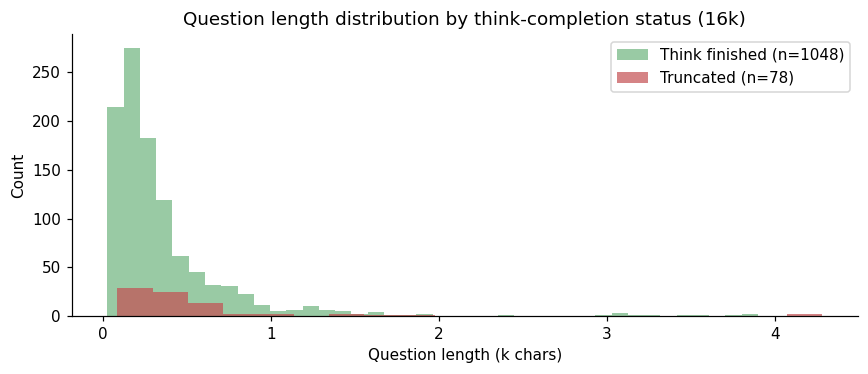

In [21]:
pub001_finished_acc = 0.695
pub002_finished_acc = df[df.think_finished].correct.mean()

print("Think-finished accuracy: 8k vs 16k")
print(f"  pub-001 (8k):  69.5%  (n=838 finished out of 1126)")
print(f"  pub-002 (16k): {pub002_finished_acc*100:.1f}%  (n={df.think_finished.sum()} finished out of {len(df)})")
print(f"  Δ: {(pub002_finished_acc - pub001_finished_acc)*100:+.1f} pp")
print()

fin_df2  = df[df.think_finished]
trunc_df2 = df[~df.think_finished]
print("Question length: finished vs truncated (16k):")
print(f"  Finished  — mean q_len: {fin_df2.q_len.mean():.0f} chars  median: {fin_df2.q_len.median():.0f}")
print(f"  Truncated — mean q_len: {trunc_df2.q_len.mean():.0f} chars  median: {trunc_df2.q_len.median():.0f}")
print()
print("Interpretation: at 8k, 25.6% truncated (harder problems excluded from finished pool).")
print("At 16k, only 6.9% truncated — harder problems now finish but score lower, diluting finished-pool accuracy.")
print(f"Despite the {(pub002_finished_acc - pub001_finished_acc)*100:+.1f} pp drop, overall accuracy rose +9.24 pp.")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(fin_df2.q_len / 1000,  bins=40, alpha=0.6, color="#55A868", label=f"Think finished (n={len(fin_df2)})")
ax.hist(trunc_df2.q_len / 1000, bins=20, alpha=0.7, color="#C44E52", label=f"Truncated (n={len(trunc_df2)})")
ax.set_xlabel("Question length (k chars)")
ax.set_ylabel("Count")
ax.set_title("Question length distribution by think-completion status (16k)")
ax.legend()
plt.tight_layout()
plt.show()

## 12. Topic accuracy delta (8k → 16k)

Side-by-side comparison of per-topic accuracy between pub-001 (8k) and pub-002 (16k). Large gains indicate topics that were primarily bottlenecked by truncation; flat or small gains indicate reasoning-bottlenecked topics that need SFT or better prompting.

Topic                             8k %    16k %    Δ pp
---------------------------------------------------------
number theory                    30.4%    56.5%   +26.1
derivatives                      58.3%    83.3%   +25.0
sequences/recurrences            34.7%    58.7%   +24.0
limits                           35.7%    57.1%   +21.4
geometry                         35.6%    50.4%   +14.8
integration                      74.5%    87.3%   +12.8
linear algebra                   52.2%    60.9%    +8.7
probability/stats                50.0%    58.5%    +8.5
other                            56.1%    62.1%    +6.0
polynomials/algebra              59.6%    63.7%    +4.1


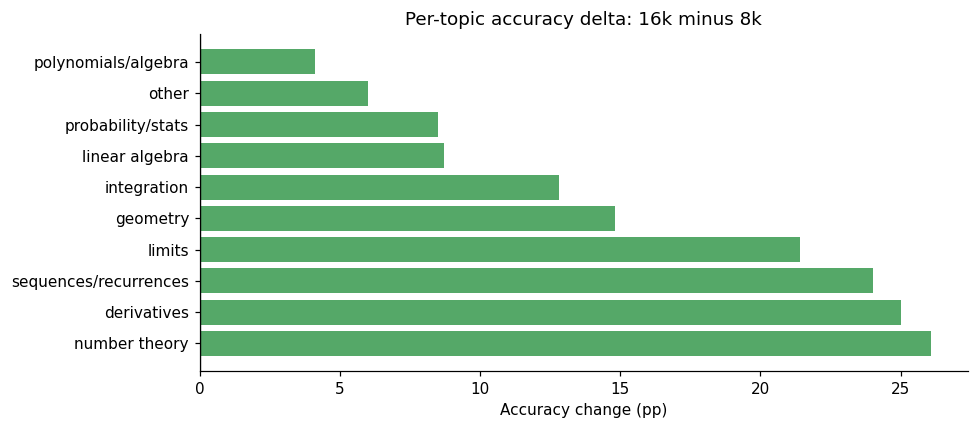

In [22]:
pub001_topics = {
    "sequences/recurrences": 34.7,
    "geometry":              35.6,
    "limits":                35.7,
    "probability/stats":     50.0,
    "linear algebra":        52.2,
    "other":                 56.1,
    "polynomials/algebra":   59.6,
    "derivatives":           58.3,
    "number theory":         30.4,
    "integration":           74.5,
}

topic_delta = []
for topic, v in topics_agg.items():
    acc16 = v["accuracy"]
    acc8  = pub001_topics.get(topic)
    delta = round(acc16 - acc8, 1) if acc8 is not None else None
    topic_delta.append({"topic": topic, "acc_8k": acc8, "acc_16k": acc16, "delta_pp": delta})

delta_df = pd.DataFrame(topic_delta).sort_values("delta_pp", ascending=False)

print(f"{'Topic':<30} {'8k %':>7} {'16k %':>8} {'Δ pp':>7}")
print("-" * 57)
for _, r in delta_df.iterrows():
    a8 = f"{r.acc_8k:.1f}%" if r.acc_8k is not None else "  n/a"
    d  = f"{r.delta_pp:+.1f}" if r.delta_pp is not None else "  n/a"
    print(f"{r.topic:<30} {a8:>7} {r.acc_16k:>7.1f}% {d:>7}")

fig, ax = plt.subplots(figsize=(9, 4))
d = delta_df.dropna(subset=["delta_pp"])
colors = ["#55A868" if v >= 0 else "#C44E52" for v in d.delta_pp]
ax.barh(d.topic, d.delta_pp, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Accuracy change (pp)")
ax.set_title("Per-topic accuracy delta: 16k minus 8k")
plt.tight_layout()
plt.show()

## 13. MCQ reasoning-error breakdown

Slices the 54 "think finished, wrong `\boxed{Letter}`" cases — now the dominant MCQ failure mode — by topic and question-length quartile. Identifies whether errors cluster in geometry/sequences (hard reasoning) or across all topics (uniform difficulty).

In [23]:
wrong_boxed = mcq[mcq.think_finished & ~mcq.correct & mcq.has_boxed_letter].copy()
wrong_boxed["topic"] = wrong_boxed["question"].apply(classify_topic)

q_bins   = [0] + list(df.q_len.quantile([0.25, 0.5, 0.75]).values) + [df.q_len.max() + 1]
q_labels = ["Q1 (short)", "Q2", "Q3", "Q4 (long)"]
wrong_boxed["q_quartile"] = pd.cut(wrong_boxed.q_len, bins=q_bins, labels=q_labels)

print(f"Wrong-boxed slice: {len(wrong_boxed)} cases (think finished, \\boxed{{Letter}} present, wrong)\n")

finished_boxed_mcq = mcq[mcq.think_finished & mcq.has_boxed_letter].copy()
finished_boxed_mcq["topic"] = finished_boxed_mcq["question"].apply(classify_topic)
topic_totals = finished_boxed_mcq.groupby("topic").size()

print("By topic (error rate = wrong / total finished-boxed in that topic):")
t_counts = wrong_boxed.topic.value_counts()
for topic, cnt in t_counts.sort_values(ascending=False).items():
    total = topic_totals.get(topic, 0)
    rate  = 100 * cnt / total if total else float("nan")
    print(f"  {topic:<30} wrong={cnt:>3}  total={total:>3}  error rate={rate:.0f}%")

print()
print("By question-length quartile:")
q_counts = wrong_boxed.q_quartile.value_counts().sort_index()
for qbin, cnt in q_counts.items():
    print(f"  {str(qbin):<15} {cnt:>3} cases")

Wrong-boxed slice: 54 cases (think finished, \boxed{Letter} present, wrong)

By topic (error rate = wrong / total finished-boxed in that topic):
  other                          wrong= 22  total= 88  error rate=25%
  sequences/recurrences          wrong= 12  total= 50  error rate=24%
  geometry                       wrong=  7  total= 32  error rate=22%
  integration                    wrong=  3  total= 51  error rate=6%
  polynomials/algebra            wrong=  3  total= 28  error rate=11%
  derivatives                    wrong=  2  total= 12  error rate=17%
  probability/stats              wrong=  2  total= 27  error rate=7%
  number theory                  wrong=  1  total= 13  error rate=8%
  limits                         wrong=  1  total=  7  error rate=14%
  linear algebra                 wrong=  1  total= 15  error rate=7%

By question-length quartile:
  Q1 (short)       14 cases
  Q2               18 cases
  Q3               17 cases
  Q4 (long)         5 cases


## 14. Free-form accuracy by blank count (explicit table)

Bar chart from §4 aggregated into a clean numeric table; groups sparse high-blank-count bins for clarity.

In [24]:
def blank_label(n):
    if n <= 5:   return str(n)
    if n <= 10:  return "6–10"
    return "11+"

blank_table = (ff.groupby("n_blanks")
    .agg(n=("correct", "count"), correct=("correct", "sum"))
    .assign(accuracy=lambda x: 100 * x.correct / x.n)
    .reset_index())
blank_table["group"] = blank_table.n_blanks.apply(blank_label)

grouped = (blank_table.groupby("group", sort=False)
    .agg(n=("n", "sum"), correct=("correct", "sum"))
    .assign(accuracy=lambda x: 100 * x.correct / x.n))

ordered_groups = ["1", "2", "3", "4", "5", "6–10", "11+"]
grouped = grouped.reindex([g for g in ordered_groups if g in grouped.index])

print(f"{'Blanks':<8} {'N':>6} {'Correct':>9} {'Accuracy':>9}")
print("-" * 36)
for grp, row in grouped.iterrows():
    print(f"{grp:<8} {row.n:>6.0f} {row.correct:>9.0f} {row.accuracy:>8.1f}%")

print()
single_acc = grouped.loc["1",    "accuracy"] if "1"    in grouped.index else float("nan")
two_acc    = grouped.loc["2",    "accuracy"] if "2"    in grouped.index else float("nan")
high_acc   = grouped.loc["6–10", "accuracy"] if "6–10" in grouped.index else float("nan")
print(f"Trend: 1-blank {single_acc:.1f}%  →  2-blank {two_acc:.1f}%  →  6–10-blank {high_acc:.1f}%")
print("Accuracy decreases monotonically with blank count; multi-blank prompting is the primary lever.")

Blanks        N   Correct  Accuracy
------------------------------------
1           337       203     60.2%
2           171       100     58.5%
3            90        56     62.2%
4            59        33     55.9%
5            31        13     41.9%
6–10         53        18     34.0%
11+          10         4     40.0%

Trend: 1-blank 60.2%  →  2-blank 58.5%  →  6–10-blank 34.0%
Accuracy decreases monotonically with blank count; multi-blank prompting is the primary lever.


## 15. MCQ letter-choice bias

For the 54 think-finished wrong-boxed cases, tally predicted vs. gold letters. Over-selection of A/B or systematic avoidance of D indicates position bias; roughly uniform errors indicate pure reasoning failure.

In [25]:
def extract_boxed_letter(resp):
    m = re.search(r"\\boxed\{([A-Z])\}", resp)
    return m.group(1) if m else None

def extract_gold_letter(gold):
    if isinstance(gold, list):
        gold = gold[0] if gold else ""
    m = re.search(r"[A-Z]", str(gold))
    return m.group(0) if m else None

fin_boxed_mcq = mcq[mcq.think_finished & mcq.has_boxed_letter].copy()
fin_boxed_mcq["pred_letter"] = fin_boxed_mcq["response"].apply(extract_boxed_letter)
fin_boxed_mcq["gold_letter"] = fin_boxed_mcq["gold"].apply(extract_gold_letter)

wrong_fb = fin_boxed_mcq[~fin_boxed_mcq.correct]

print("Gold-letter distribution (all finished-boxed MCQ):")
print(fin_boxed_mcq.gold_letter.value_counts().sort_index().to_string())
print()
print("Predicted-letter distribution (wrong cases only):")
print(wrong_fb.pred_letter.value_counts().sort_index().to_string())
print()

print("Wrong-case confusion matrix (gold → predicted):")
conf = wrong_fb.groupby(["gold_letter", "pred_letter"]).size().unstack(fill_value=0)
print(conf.to_string())
print()

print("Per-letter accuracy (finished-boxed MCQ):")
for letter in sorted(fin_boxed_mcq.gold_letter.dropna().unique()):
    sub = fin_boxed_mcq[fin_boxed_mcq.gold_letter == letter]
    print(f"  Gold={letter}  n={len(sub):>3}  acc={100*sub.correct.mean():.1f}%")

Gold-letter distribution (all finished-boxed MCQ):
gold_letter
A    30
B    26
C    41
D    30
E    35
F    44
G    37
H    23
I    27
J    30

Predicted-letter distribution (wrong cases only):
pred_letter
A     4
B    11
C     8
D     4
E     3
F     6
G     7
H     2
I     2
J     7

Wrong-case confusion matrix (gold → predicted):
pred_letter  A  B  C  D  E  F  G  H  I  J
gold_letter                              
A            0  1  3  0  1  0  1  0  1  0
B            0  0  1  0  0  0  0  0  0  1
C            1  1  0  1  0  0  1  1  0  0
D            0  1  2  0  0  2  0  0  0  1
E            1  1  1  0  0  1  3  0  0  0
F            1  2  1  0  2  0  0  0  0  3
G            0  2  0  0  0  1  0  1  1  2
H            1  2  0  1  0  0  2  0  0  0
I            0  0  0  0  0  2  0  0  0  0
J            0  1  0  2  0  0  0  0  0  0

Per-letter accuracy (finished-boxed MCQ):
  Gold=A  n= 30  acc=76.7%
  Gold=B  n= 26  acc=92.3%
  Gold=C  n= 41  acc=87.8%
  Gold=D  n= 30  acc=80.0%
  Gold=E  